In [1]:
from __future__ import annotations

import operator
from typing import TypedDict, List, Annotated

from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage

In [2]:
class Task(BaseModel):
    id:int
    title:str
    brief:str=Field(...,description="what to cover")

In [3]:
class Plan(BaseModel):
    blog_title:str
    tasks:List[Task]

In [4]:
class State(TypedDict):
    topic:str
    plan:Plan
    sections:Annotated[List[str],operator.add]
    final:str

In [30]:
llm=ChatGroq(model="openai/gpt-oss-20b")

In [6]:
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.1', 'langchain': '1.3.18'}}, client=<groq.resources.chat.completions.Completions object at 0x000001EC1BEBC980>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001EC1BEBD6A0>, model_name='groq:openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [7]:
def planner(state:State)->dict:
    plan=llm.with_structured_output(Plan).invoke(
        [
            SystemMessage(
                content=("Create a blog plan with 5-7 sections on the following topic.")   
            ),
            HumanMessage(content=f"Topic: {state['topic']}"),
        ]
    )
    return {"plan":plan}

In [ ]:
def fanout(state: State):
    return [Send("worker", {"task": task, "topic": state["topic"], "plan": state["plan"]})
            for task in state["plan"].tasks]

def worker(payload: dict) -> dict:

    task = payload["task"]
    topic = payload["topic"]
    plan = payload["plan"]

    blog_title = plan.blog_title

    section_md = llm.invoke(
        [
            SystemMessage(content="Write one clean Markdown section."),
            HumanMessage(
                content=(
                    f"Blog: {blog_title}\n"
                    f"Topic: {topic}\n\n"
                    f"Section: {task.title}\n"
                    f"Brief: {task.brief}\n\n"
                    "Return only the section content in Markdown."
                )
            ),
        ]
    ).content.strip()

    return {"sections": [section_md]}

from pathlib import Path

def reducer(state: State) -> dict:
    
    title = state["plan"].blog_title
    body = "\n\n".join(state["sections"]).strip()

    final_md = f"# {title}\n\n{body}\n"
    filename = title.lower().replace(" ", "_") + ".md"
    output_path = Path(filename)
    output_path.write_text(final_md, encoding="utf-8")

    return {"final": final_md}


In [ ]:
graph = StateGraph(State)
graph.add_node("planner", planner)
graph.add_node("worker", worker)
graph.add_node("reducer", reducer)

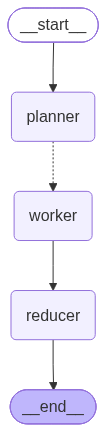

In [ ]:
graph.add_edge(START, "planner")
graph.add_conditional_edges("planner", fanout, ["worker"])
graph.add_edge("worker", "reducer")
graph.add_edge("reducer", END)


app=graph.compile()

app=graph

In [ ]:
out = app.invoke({"topic": "Write a blog on self attention", "sections": []})



In [36]:
out


{'topic': 'Write a blog on Self Attention',
 'plan': Plan(blog_title='Self‑Attention: The Engine Behind Modern NLP', tasks=[Task(id=1, title='Introduction to Attention', brief='Explain the concept of attention, its origins in sequence‑to‑sequence models, and why it matters.'), Task(id=2, title='The Self‑Attention Mechanism', brief='Break down query/key/value vectors, dot‑product attention, scaling, and the role of softmax.'), Task(id=3, title='Transformer Architecture Overview', brief='Show how self‑attention is stacked in encoder/decoder layers, multi‑head attention, and residual connections.'), Task(id=4, title='Practical Applications', brief='Discuss language modeling, translation, summarization, and vision tasks that use self‑attention.'), Task(id=5, title='Advanced Variants', brief='Cover sparse attention, efficient transformers, and relative positional encodings.'), Task(id=6, title='Implementation Tips', brief='Provide code snippets in PyTorch/TensorFlow and common pitfalls.'), 

In [38]:
print(out)

{'topic': 'Write a blog on Self Attention', 'plan': Plan(blog_title='Self‑Attention: The Engine Behind Modern NLP', tasks=[Task(id=1, title='Introduction to Attention', brief='Explain the concept of attention, its origins in sequence‑to‑sequence models, and why it matters.'), Task(id=2, title='The Self‑Attention Mechanism', brief='Break down query/key/value vectors, dot‑product attention, scaling, and the role of softmax.'), Task(id=3, title='Transformer Architecture Overview', brief='Show how self‑attention is stacked in encoder/decoder layers, multi‑head attention, and residual connections.'), Task(id=4, title='Practical Applications', brief='Discuss language modeling, translation, summarization, and vision tasks that use self‑attention.'), Task(id=5, title='Advanced Variants', brief='Cover sparse attention, efficient transformers, and relative positional encodings.'), Task(id=6, title='Implementation Tips', brief='Provide code snippets in PyTorch/TensorFlow and common pitfalls.'), T

{'topic': 'Write a blog on Self Attention',
 'plan': Plan(blog_title='Self‑Attention: The Engine Behind Modern NLP', tasks=[Task(id=1, title='Introduction to Attention', brief='Explain the concept of attention, its origins in sequence‑to‑sequence models, and why it matters.'), Task(id=2, title='The Self‑Attention Mechanism', brief='Break down query/key/value vectors, dot‑product attention, scaling, and the role of softmax.'), Task(id=3, title='Transformer Architecture Overview', brief='Show how self‑attention is stacked in encoder/decoder layers, multi‑head attention, and residual connections.'), Task(id=4, title='Practical Applications', brief='Discuss language modeling, translation, summarization, and vision tasks that use self‑attention.'), Task(id=5, title='Advanced Variants', brief='Cover sparse attention, efficient transformers, and relative positional encodings.'), Task(id=6, title='Implementation Tips', brief='Provide code snippets in PyTorch/TensorFlow and common pitfalls.'), 